# Seaborn XP Gold - Marvel Cinematic Universe Box Office Analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('mcu_box_office.csv')

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (27, 10)

Column names:
['movie_title', 'mcu_phase', 'release_date', 'tomato_meter', 'audience_score', 'movie_duration', 'production_budget', 'opening_weekend', 'domestic_box_office', 'worldwide_box_office']

First few rows:


,movie_title,mcu_phase,release_date,tomato_meter,audience_score,movie_duration,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
0,Iron Man,1,5/2/2008,94,91,126,"186,000,000","102,118,668","318,604,126","585,171,547"
1,The Incredible Hulk,1,6/13/2008,67,70,112,"137,500,000","55,414,050","134,806,913","265,573,859"
2,Iron Man 2,1,5/7/2010,72,71,124,"170,000,000","128,122,480","312,433,331","621,156,389"
3,Thor,1,5/6/2011,77,76,113,"150,000,000","65,723,338","181,030,624","449,326,618"
4,Captain America: The First Avenger,1,7/22/2011,79,75,124,"140,000,000","65,058,524","176,654,505","370,569,776"


In [2]:
# converting financial columns to numeric
financial_cols = ['production_budget', 'opening_weekend', 'domestic_box_office', 'worldwide_box_office']

for col in financial_cols:
    df[col] = df[col].str.replace(',', '').str.replace('"', '').astype(int)

# Converting release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'])

print("Data types after preprocessing:")
print(df.dtypes)
print(f"\nFinancial data sample:")
df[financial_cols].head()

Data types after preprocessing:
movie_title                     object
mcu_phase                        int64
release_date            datetime64[ns]
tomato_meter                     int64
audience_score                   int64
movie_duration                   int64
production_budget                int64
opening_weekend                  int64
domestic_box_office              int64
worldwide_box_office             int64
dtype: object

Financial data sample:


,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
0,186000000,102118668,318604126,585171547
1,137500000,55414050,134806913,265573859
2,170000000,128122480,312433331,621156389
3,150000000,65723338,181030624,449326618
4,140000000,65058524,176654505,370569776


## Exercise 1: Visualizing Movie Durations

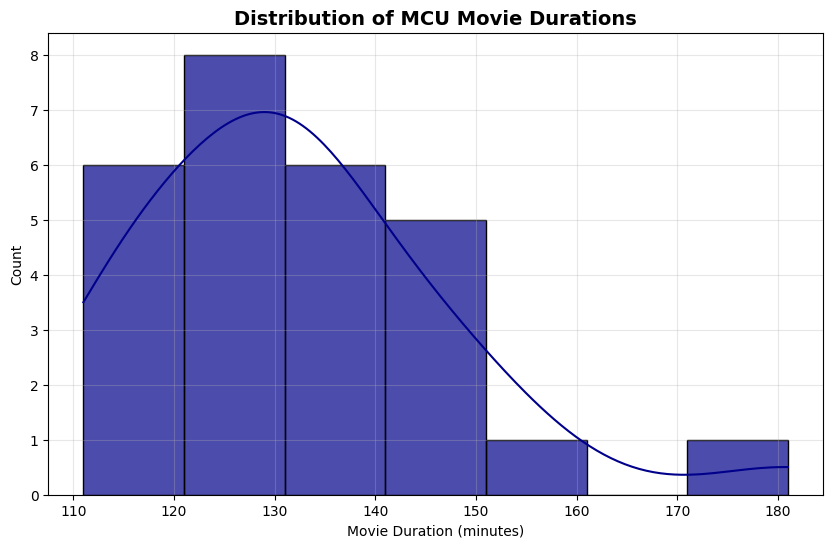

In [3]:
# Exercise 1: Movie Duration Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='movie_duration', kde=True, color='darkblue', alpha=0.7)
plt.title('Distribution of MCU Movie Durations', fontsize=14, fontweight='bold')
plt.xlabel('Movie Duration (minutes)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

## Exercise 2: Box Plot of Audience and Tomato Meter Scores

C:\Users\PC\AppData\Local\Temp\ipykernel_10656\1427704829.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scores_melted, x='Score_Type', y='Score', palette='Set2')


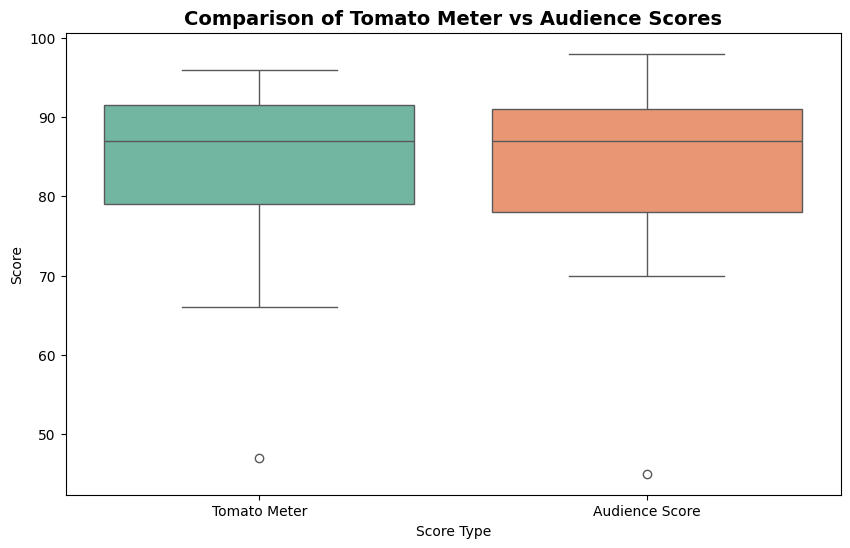

In [4]:

scores_melted = df[['movie_title', 'tomato_meter', 'audience_score']].melt(
    id_vars='movie_title', 
    value_vars=['tomato_meter', 'audience_score'],
    var_name='Score_Type', 
    value_name='Score'
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=scores_melted, x='Score_Type', y='Score', palette='Set2')
plt.title('Comparison of Tomato Meter vs Audience Scores', fontsize=14, fontweight='bold')
plt.xlabel('Score Type')
plt.ylabel('Score')
plt.xticks([0, 1], ['Tomato Meter', 'Audience Score'])
plt.show()

## Exercise 3: Pair Plot of Financial Data

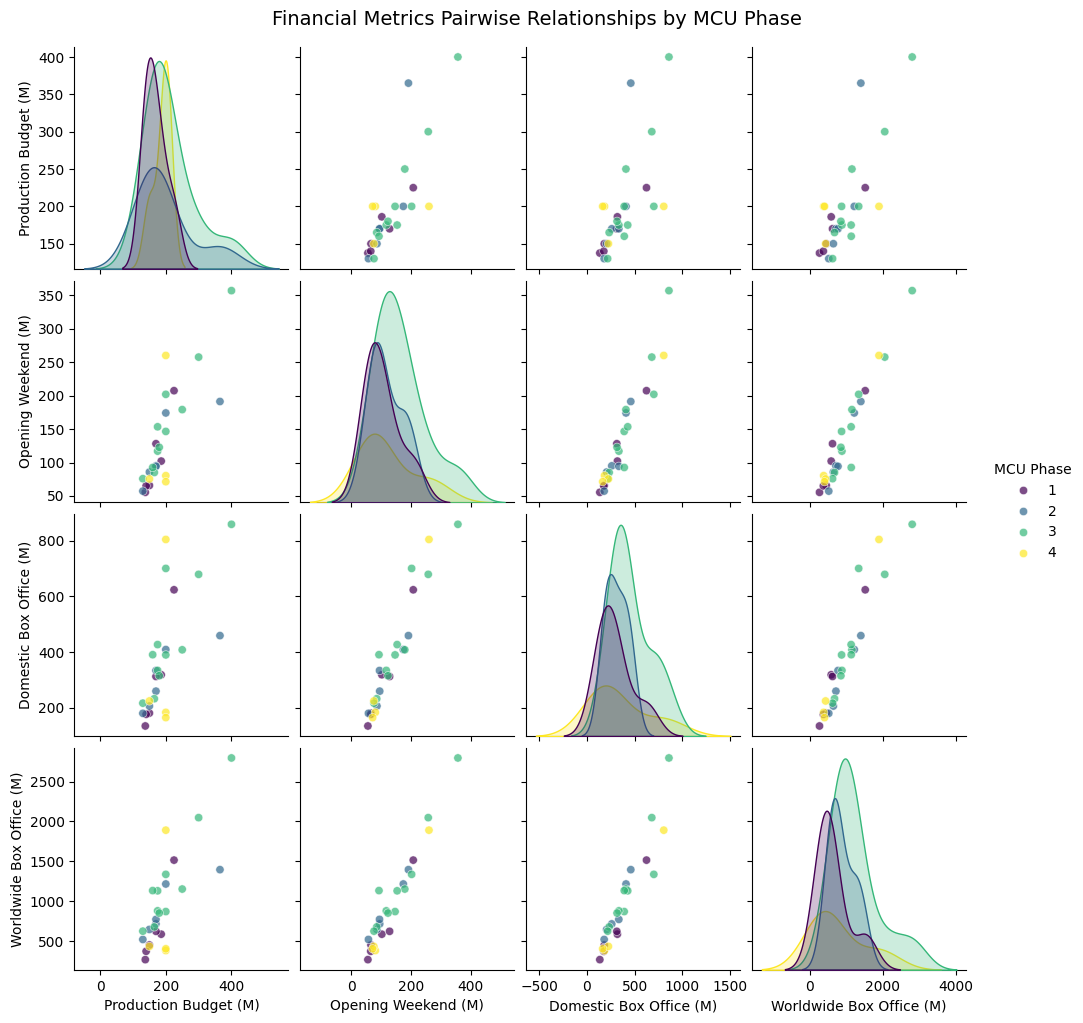

In [5]:
financial_subset = df[financial_cols + ['mcu_phase']].copy()

# Converting values to millions for better readability
for col in financial_cols:
    financial_subset[col] = financial_subset[col] / 1_000_000

financial_subset.columns = ['Production Budget (M)', 'Opening Weekend (M)', 
                           'Domestic Box Office (M)', 'Worldwide Box Office (M)', 'MCU Phase']

sns.pairplot(financial_subset, hue='MCU Phase', palette='viridis', plot_kws={'alpha': 0.7})
plt.suptitle('Financial Metrics Pairwise Relationships by MCU Phase', y=1.02, fontsize=14)
plt.show()

## Exercise 4: Heatmap of Correlation Between Financial Metrics

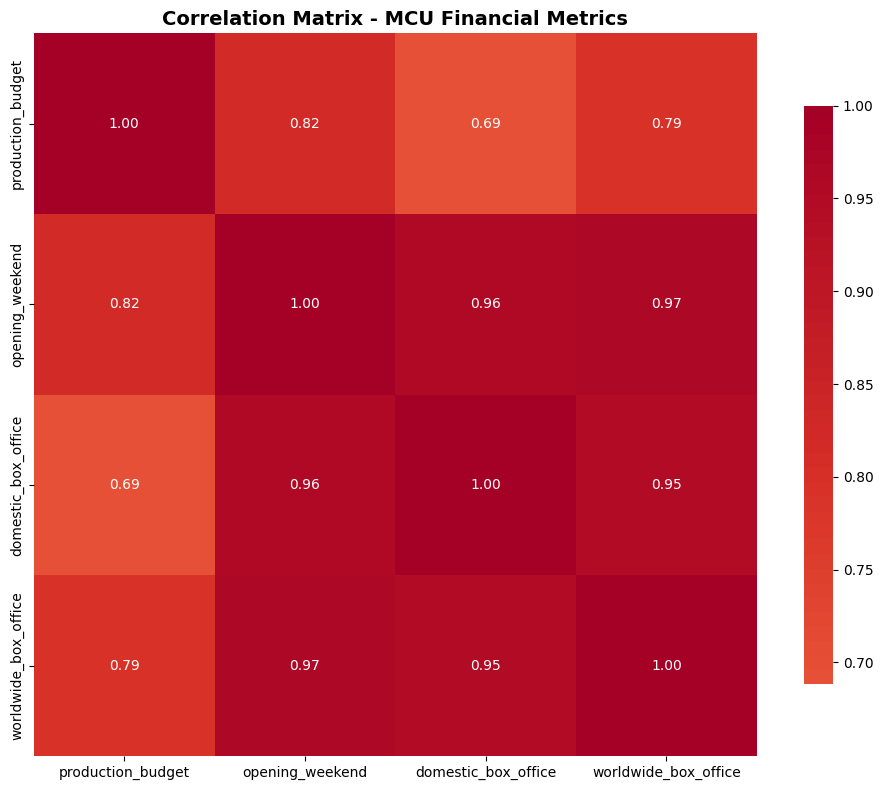

Key Financial Correlations:
production_budget vs opening_weekend: 0.819
production_budget vs domestic_box_office: 0.688
production_budget vs worldwide_box_office: 0.795
opening_weekend vs domestic_box_office: 0.955
opening_weekend vs worldwide_box_office: 0.968
domestic_box_office vs worldwide_box_office: 0.947


In [6]:
correlation_matrix = df[financial_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - MCU Financial Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#  correlation 
print("Key Financial Correlations:")
for i in range(len(financial_cols)):
    for j in range(i+1, len(financial_cols)):
        corr_val = correlation_matrix.iloc[i, j]
        print(f"{financial_cols[i]} vs {financial_cols[j]}: {corr_val:.3f}")

## Exercise 5: Line Plot of Box Office Trends Over Time

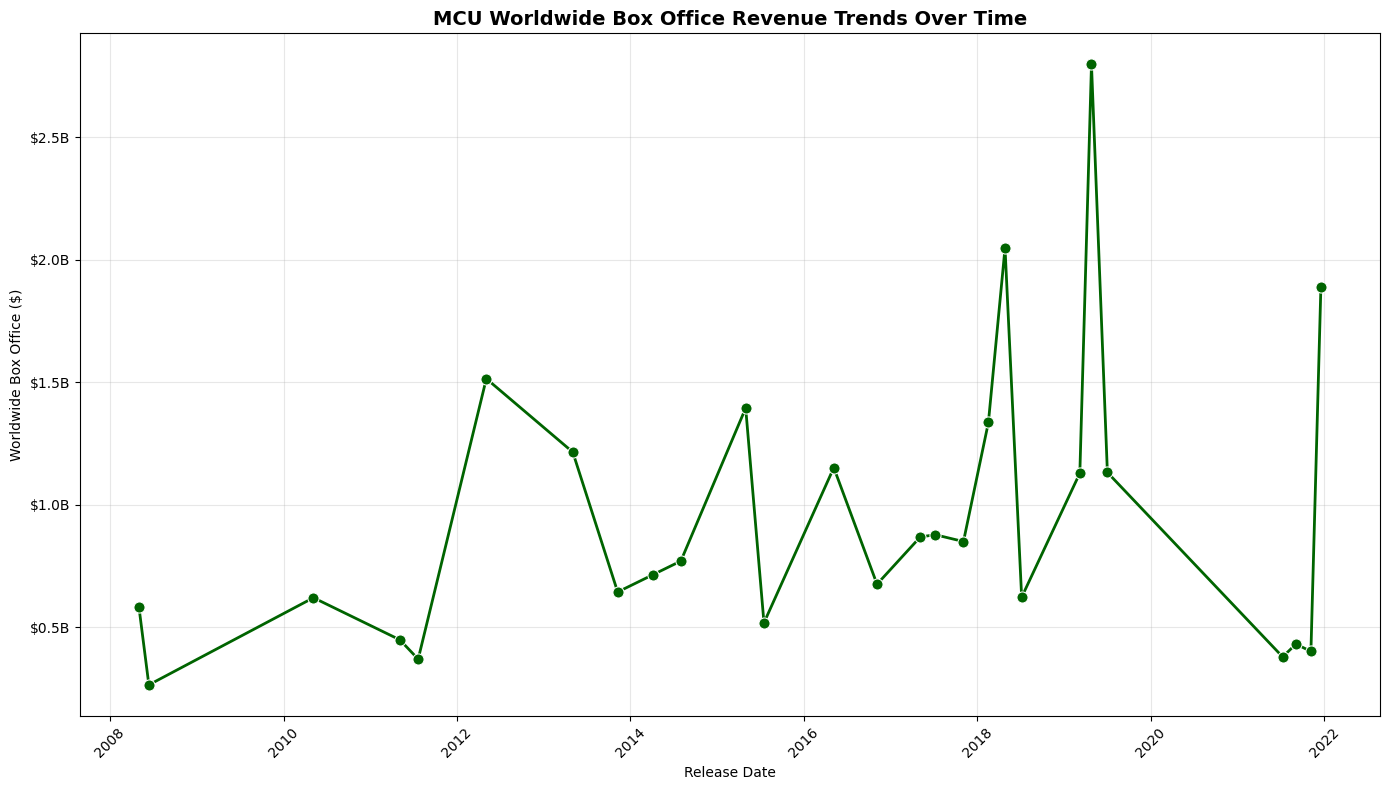

In [7]:
#  Box Office Trends Over Time
df_sorted = df.sort_values('release_date').copy()

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_sorted, x='release_date', y='worldwide_box_office', 
             marker='o', markersize=8, linewidth=2, color='darkgreen')

plt.title('MCU Worldwide Box Office Revenue Trends Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Release Date')
plt.ylabel('Worldwide Box Office ($)')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B'))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercise 6: Violin Plot of Movie Durations by MCU Phase

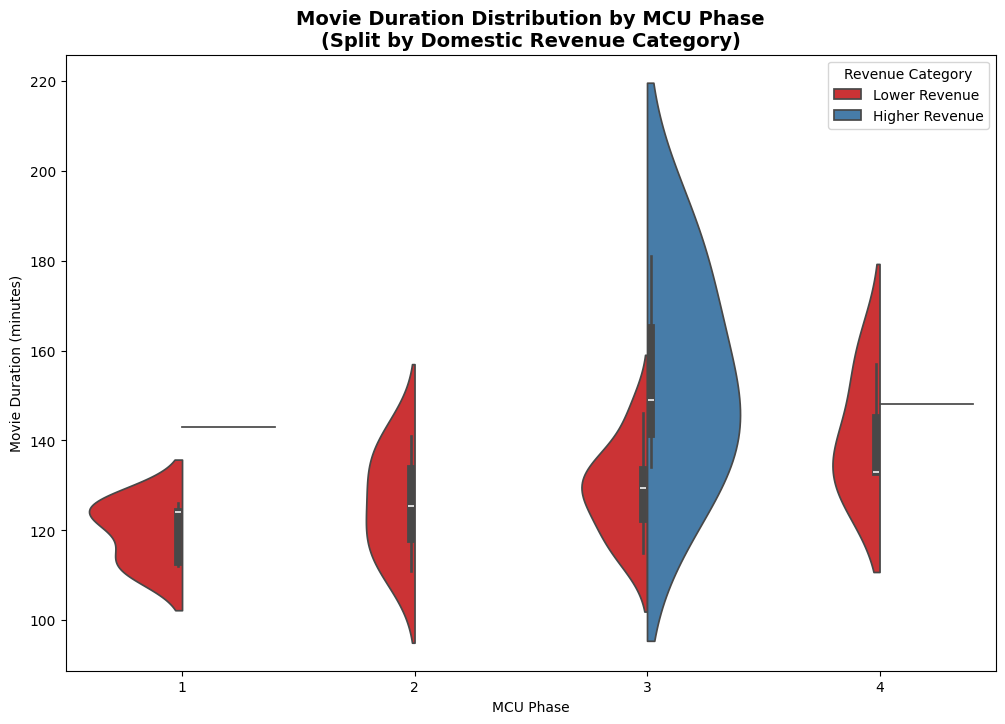

Duration statistics by MCU Phase:
            mean   std  min  max
mcu_phase                       
1          123.7  11.2  112  143
2          125.8  11.4  111  141
3          135.8  18.2  115  181
4          142.8  11.8  133  157


In [8]:
# Creating revenue category for split violin
df['revenue_category'] = pd.cut(df['domestic_box_office'], 
                               bins=2, 
                               labels=['Lower Revenue', 'Higher Revenue'])

plt.figure(figsize=(12, 8))
sns.violinplot(data=df, x='mcu_phase', y='movie_duration', 
               hue='revenue_category', split=True, palette='Set1')

plt.title('Movie Duration Distribution by MCU Phase\n(Split by Domestic Revenue Category)', 
          fontsize=14, fontweight='bold')
plt.xlabel('MCU Phase')
plt.ylabel('Movie Duration (minutes)')
plt.legend(title='Revenue Category', loc='upper right')
plt.show()

print("Duration statistics by MCU Phase:")
duration_stats = df.groupby('mcu_phase')['movie_duration'].agg(['mean', 'std', 'min', 'max']).round(1)
print(duration_stats)